In [4]:
import os, sys
sys.path.append("/workspace/projects/clip_dinoiser")

from models.builder import build_model
from helpers.visualization import mask2rgb
from segmentation.datasets import PascalVOCDataset
from hydra import compose, initialize, initialize_config_dir
from hydra.core.global_hydra import GlobalHydra
from PIL import Image
import matplotlib.pyplot as plt
from torchvision import transforms as T
import torch.nn.functional as F
import numpy as np
from operator import itemgetter 
import torch
import warnings
warnings.filterwarnings('ignore')
# initialize(config_path="configs", version_base=None)
# Clear global Hydra state if already initialized (useful when re-running cells)
if GlobalHydra.instance().is_initialized():
    GlobalHydra.instance().clear()
initialize_config_dir(config_dir="/workspace/projects/clip_dinoiser/configs", version_base=None)

hydra.initialize_config_dir()

In [14]:
def visualize_per_image(file_path, text_prompts, palette, model, device):
    assert os.path.isfile(file_path), f"No such file: {file_path}"

    img = Image.open(file_path).convert('RGB')
    img_tens = T.PILToTensor()(img).unsqueeze(0).to(device) / 255.

    h, w = img_tens.shape[-2:]
    output = model(img_tens).cpu()
    output = F.interpolate(output, scale_factor=model.vit_patch_size, mode="bilinear",
                           align_corners=False)[..., :h, :w]
    output = output[0].argmax(dim=0)
    mask = mask2rgb(output, palette)

    classes = np.unique(output).tolist()
    fig = plt.figure(figsize=(len(classes), 1))
    plt.imshow(np.array(itemgetter(*classes)(palette)).reshape(1, -1, 3))
    plt.xticks(np.arange(len(classes)), list(itemgetter(*classes)(text_prompts)), rotation=45)
    plt.yticks([])

    return mask, fig, img

In [15]:
# check_path = '/workspace/projects/clip_dinoiser/checkpoints/last.pt'
device = "cpu"#"cuda"
dinoclip_cfg = "clip_dinoiser.yaml"
cfg = compose(config_name=dinoclip_cfg)
# Build model while temporarily switching cwd to the project so relative config paths resolve
orig_cwd = os.getcwd()
try:
    os.chdir('/workspace/projects/clip_dinoiser')
    check_path = './checkpoints/last.pt'
    check = torch.load(check_path, map_location='cpu')
    model = build_model(cfg.model, class_names=PascalVOCDataset.CLASSES).to(device)
finally:
    os.chdir(orig_cwd)
model.clip_backbone.decode_head.use_templates=False # switching off the imagenet templates for fast inference
model.load_state_dict(check['model_state_dict'], strict=False)
model = model.eval()

(-0.5, 511.5, 511.5, -0.5)

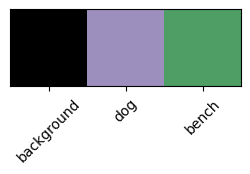

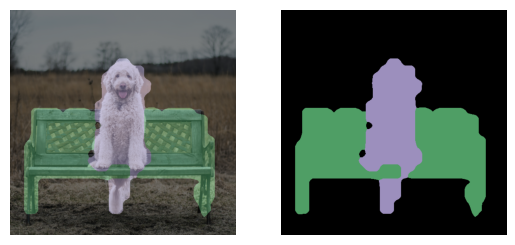

In [16]:
file = '/workspace/projects/Grounded-Segment-Anything/assets/inpaint_demo.jpg'
PALETTE = [(0, 0, 0), (156, 143, 189), (79, 158, 101)]

# specify your prompts
TEXT_PROMPTS = ['background', 'dog', 'bench']
model.clip_backbone.decode_head.update_vocab(TEXT_PROMPTS)
model.to(device)

# set apply FOUND (background detector) to True
model.apply_found = True

# run segmentation
mask, ticks, img = visualize_per_image(file, TEXT_PROMPTS, PALETTE, model, device)

fig, ax = plt.subplots(nrows=1, ncols=2)
alpha=0.5
blend = (alpha)*np.array(img)/255. + (1-alpha) * mask/255.
ax[0].imshow(blend)
ax[1].imshow(mask)
ax[0].axis('off')
ax[1].axis('off')

(-0.5, 511.5, 511.5, -0.5)

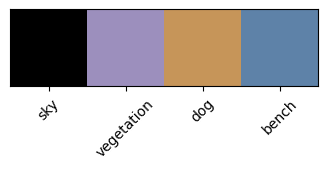

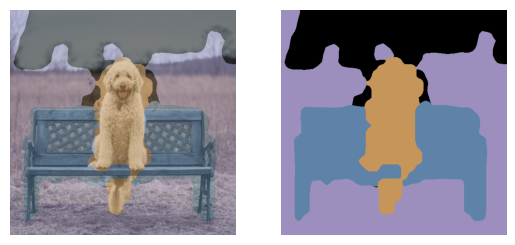

In [19]:
file = '/workspace/projects/Grounded-Segment-Anything/assets/inpaint_demo.jpg'
PALETTE = [(0, 0, 0), (156, 143, 189), (79, 158, 101), (198, 149, 89), (94, 130, 168), (214, 199, 133)]

# specify your prompts
TEXT_PROMPTS = ['sky', 'vegetation', 'mountain', 'dog', 'bench']
model.clip_backbone.decode_head.update_vocab(TEXT_PROMPTS)
model.to(device)

# set apply FOUND (background detector) to True
model.apply_found = False

# run segmentation
mask, ticks, img = visualize_per_image(file, TEXT_PROMPTS, PALETTE, model, device)

fig, ax = plt.subplots(nrows=1, ncols=2)
alpha=0.5
blend = (alpha)*np.array(img)/255. + (1-alpha) * mask/255.
ax[0].imshow(blend)
ax[1].imshow(mask)
ax[0].axis('off')
ax[1].axis('off')